<a href="https://colab.research.google.com/github/AkemjotSingh/csot-ml-astronomy-akemjotsingh/blob/main/week2_baseline_starter_akemjotsingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 2 . Part 1: Baseline with Scikit-Learn (Starter)

**Goal:** Flatten the galaxy images into NumPy feature rows, train simple scikit-learn classifiers (KNN, Logistic Regression), and record the **baseline accuracy** that every later model must beat.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). The GPU isn't strictly needed for sklearn, but we reuse the Week 1 GPU pipeline.
2. Read [`01-tensors-to-numpy-and-flattening.md`](../01-tensors-to-numpy-and-flattening.md) and [`02-baseline-with-scikit-learn.md`](../02-baseline-with-scikit-learn.md).

Each `TODO` cell has a short instruction. Replace the placeholder with working code, then run the cell. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 — Re-create the Week 1 data pipeline

Week 2 builds directly on the `DataLoader`s from Week 1. The cells below reproduce that pipeline (download is commented out — uncomment it the first time, exactly as in [`week1_data_solution.ipynb`](../../Week-1/notebooks/week1_data_solution.ipynb)). If you saved `galaxy_data/` to Google Drive in Week 1, just re-mount Drive and point `DATA_ROOT` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
#
# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)
from google.colab import files

files.upload()

os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

!pip install kaggle -q
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q galaxy-zoo-2-images.zip -d galaxy_raw

!wget -q "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz" -O galaxy_raw/gz2_hart16.csv.gz
!gunzip galaxy_raw/gz2_hart16.csv.gz

RAW_ROOT   = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT  = Path("galaxy_data")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:34<00:00, 94.9MB/s]



In [5]:
def high_level_label(gz2_class):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, ...) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    return df.dropna(subset=["label"]).reset_index(drop=True)


def _link_image(src, dst):
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(Path(src).resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(images_dir, df, out_root, per_class=200,
                                   train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    images_dir, out_root = Path(images_dir), Path(out_root)
    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)
        n = len(rows)
        n_train, n_val = int(train_frac * n), int(val_frac * n)
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train:n_train + n_val],
            "test": rows.iloc[n_train + n_val:],
        }
        for split_name, split_rows in splits.items():
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists():
                    _link_image(src, dst)


PER_CLASS = 200  # bump up (e.g. 2000) once everything works

df = load_labeled_table(RAW_ROOT / "gz2_filename_mapping.csv", RAW_ROOT / "gz2_hart16.csv")
build_split_imagefolder_layout(IMAGES_DIR, df, DATA_ROOT, per_class=PER_CLASS)
print(df["label"].value_counts())

label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64


In [6]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
print("classes      :", train_ds.classes)
print("class_to_idx :", train_ds.class_to_idx)
print("num_classes  :", num_classes)

classes      : ['elliptical', 'spiral', 'spiral_barred']
class_to_idx : {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}
num_classes  : 3


## Step 1 - From DataLoader to NumPy feature matrices

scikit-learn wants a 2D array `X` of shape `(n_samples, n_features)` and a 1D array `y` of labels. We get there by iterating the loader, flattening each batch with `flatten(start_dim=1)` (keeping the batch dim), and concatenating.

In [7]:
# TODO: write loader_to_numpy(loader) that returns (X, y) as NumPy arrays.
#   - for each (images, labels) batch: flat = images.flatten(start_dim=1)
#   - collect flat.numpy() and labels.numpy(), then np.concatenate along axis 0
# Then build X_train, y_train from train_loader and X_test, y_test from test_loader.
# Print X_train.shape and X_test.shape (expect (N, 12288)).
def loader_to_numpy(loader):
    xs, ys = [], []
    for images, labels in loader:               # images: (B, 3, 64, 64)
        flat = images.flatten(start_dim=1)       # (B, 12288)
        xs.append(flat.numpy())
        ys.append(labels.numpy())
    X = np.concatenate(xs, axis=0)               # (N, 12288)
    y = np.concatenate(ys, axis=0)               # (N,)
    return X, y

X_train, y_train = loader_to_numpy(train_loader)
X_test,  y_test  = loader_to_numpy(test_loader)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
assert X_train.shape[1] == 3 * 64 * 64

X_train: (420, 12288) y_train: (420,)
X_test : (90, 12288) y_test : (90,)


## Step 2 - The 'do-nothing' floors

Before any real model: the majority-class baseline. A model that always predicts the most common class already scores this much - so this, not random chance, is the number to beat.

In [8]:
# TODO: fit a DummyClassifier(strategy="most_frequent") on (X_train, y_train)
#       and print its accuracy on (X_test, y_test). Also print 1/num_classes (random).
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
majority_acc = dummy.score(X_test, y_test)
print(f"Random-guess accuracy   : {1/num_classes:.3f}")
print(f"Majority-class accuracy : {majority_acc:.3f}")

Random-guess accuracy   : 0.333
Majority-class accuracy : 0.333


## Step 3 - K-Nearest Neighbours

KNN classifies a galaxy by majority vote of its `k` closest training galaxies in 12 288-D pixel space. There is no real 'training' - it just memorises the data.

In [13]:
# TODO: fit KNeighborsClassifier(n_neighbors=5) on the train set and print its TEST accuracy.
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)   # k = 5
knn.fit(X_train, y_train)                    # just memorises the data
acc_k = knn.score(X_test, y_test)              # fraction correct on the test set
print(f"KNN (k=5) accuracy: {acc_k:.3f}")

KNN (k=5) accuracy: 0.411


## Step 4 - Logistic Regression

A linear classifier: a weighted sum of the 12 288 pixel features per class, squashed by a softmax. Effectively a single-layer neural network. `max_iter` is raised because high-dimensional data is slow to converge.

In [14]:
# TODO: fit LogisticRegression(max_iter=1000) on the train set and print its TEST accuracy.
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)   # more iters: high-dim data is slow to converge
logreg.fit(X_train, y_train)
acc_l = logreg.score(X_test, y_test)
print(f"Logistic Regression accuracy: {acc_l:.3f}")

Logistic Regression accuracy: 0.456


## Step 5 - The comparison table (the bar to beat)

Put the numbers side by side. The best of these is the baseline your Week 3 CNN must clearly beat.

In [15]:
# TODO: print a small table comparing: random (1/num_classes), majority, KNN, LogReg.
#       Identify (in a print statement) the single number Week 3 must beat.
results = {
    "random_guess":   1 / num_classes,
    "majority_class": majority_acc,
    "knn_k5":         acc_k,
    "logistic_reg":   acc_l,
}
print(pd.Series(results).round(3).to_string())
best = max(results, key=results.get)
print(f"\nBaseline to beat in Week 3: {results[best]:.3f}  (from {best})")

random_guess      0.333
majority_class    0.333
knn_k5            0.411
logistic_reg      0.456

Baseline to beat in Week 3: 0.456  (from logistic_reg)


## Step 6 (stretch) - Confusion matrix

Accuracy hides *which* classes get confused. Plot a confusion matrix for the logistic-regression predictions and note the most-confused pair - we'll compare it to the CNN's matrix in Week 3.

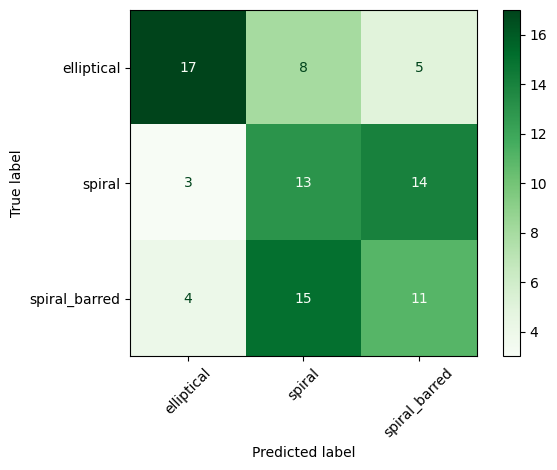

In [19]:
# TODO (optional): plot a confusion matrix for KNN or LogReg predictions.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = logreg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=train_ds.classes)
disp.plot(cmap="Greens", xticks_rotation=45)
plt.tight_layout()
plt.show()

## Reflection *(write 2-3 sentences each)*

1. What baseline accuracy did you reach, and how far above the majority-class floor is it?
2. Why does flattening hurt a *galaxy* classifier specifically? (Hint: isophote shape, arms - see [`03-surface-brightness-and-isophotes.md`](../03-surface-brightness-and-isophotes.md).)
3. Which two classes do you expect a CNN to still find hardest to separate, and why?

Answer 1: 0.456, 0.456-0.333=0.123

Answer 2: Isophotes destructured, adjacent pixels are separated

Answer 3: Face-on lenticulars vs Ellipticals, Spiral vs Spiral barred